In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
# Load data from simulation with driven bulk
data = np.load('pp_tb_th_nmos_bulk.npz')

# List all array names in the file
print(data.files)  # Output: ['array1', 'array2']

# Access a specific array
hd3_bulk = data['hd3']
bins = data['bins']
data.close()

['sfdr', 'hd3', 'bins']


In [36]:
# Load data from simulation with driven bulk
data = np.load('pp_tb_th_nmos.npz')

# List all array names in the file
print(data.files)  # Output: ['array1', 'array2']

# Access a specific array
hd3 = data['hd3']
data.close()

['sfdr', 'hd3', 'bins']


In [37]:
# Analytical data
vov = 0.4344
vm = 0.20
fs = 500e6
nfft = 32
fin = bins*fs/nfft
c = 5e-12
gds = 85e-3
fbw=1/(2*np.pi*c/gds)
hd3_calc = -20*np.log10((1/4)*fin/fbw*(vm/vov)**2)
print(fbw/1e6)

2705.634032562221


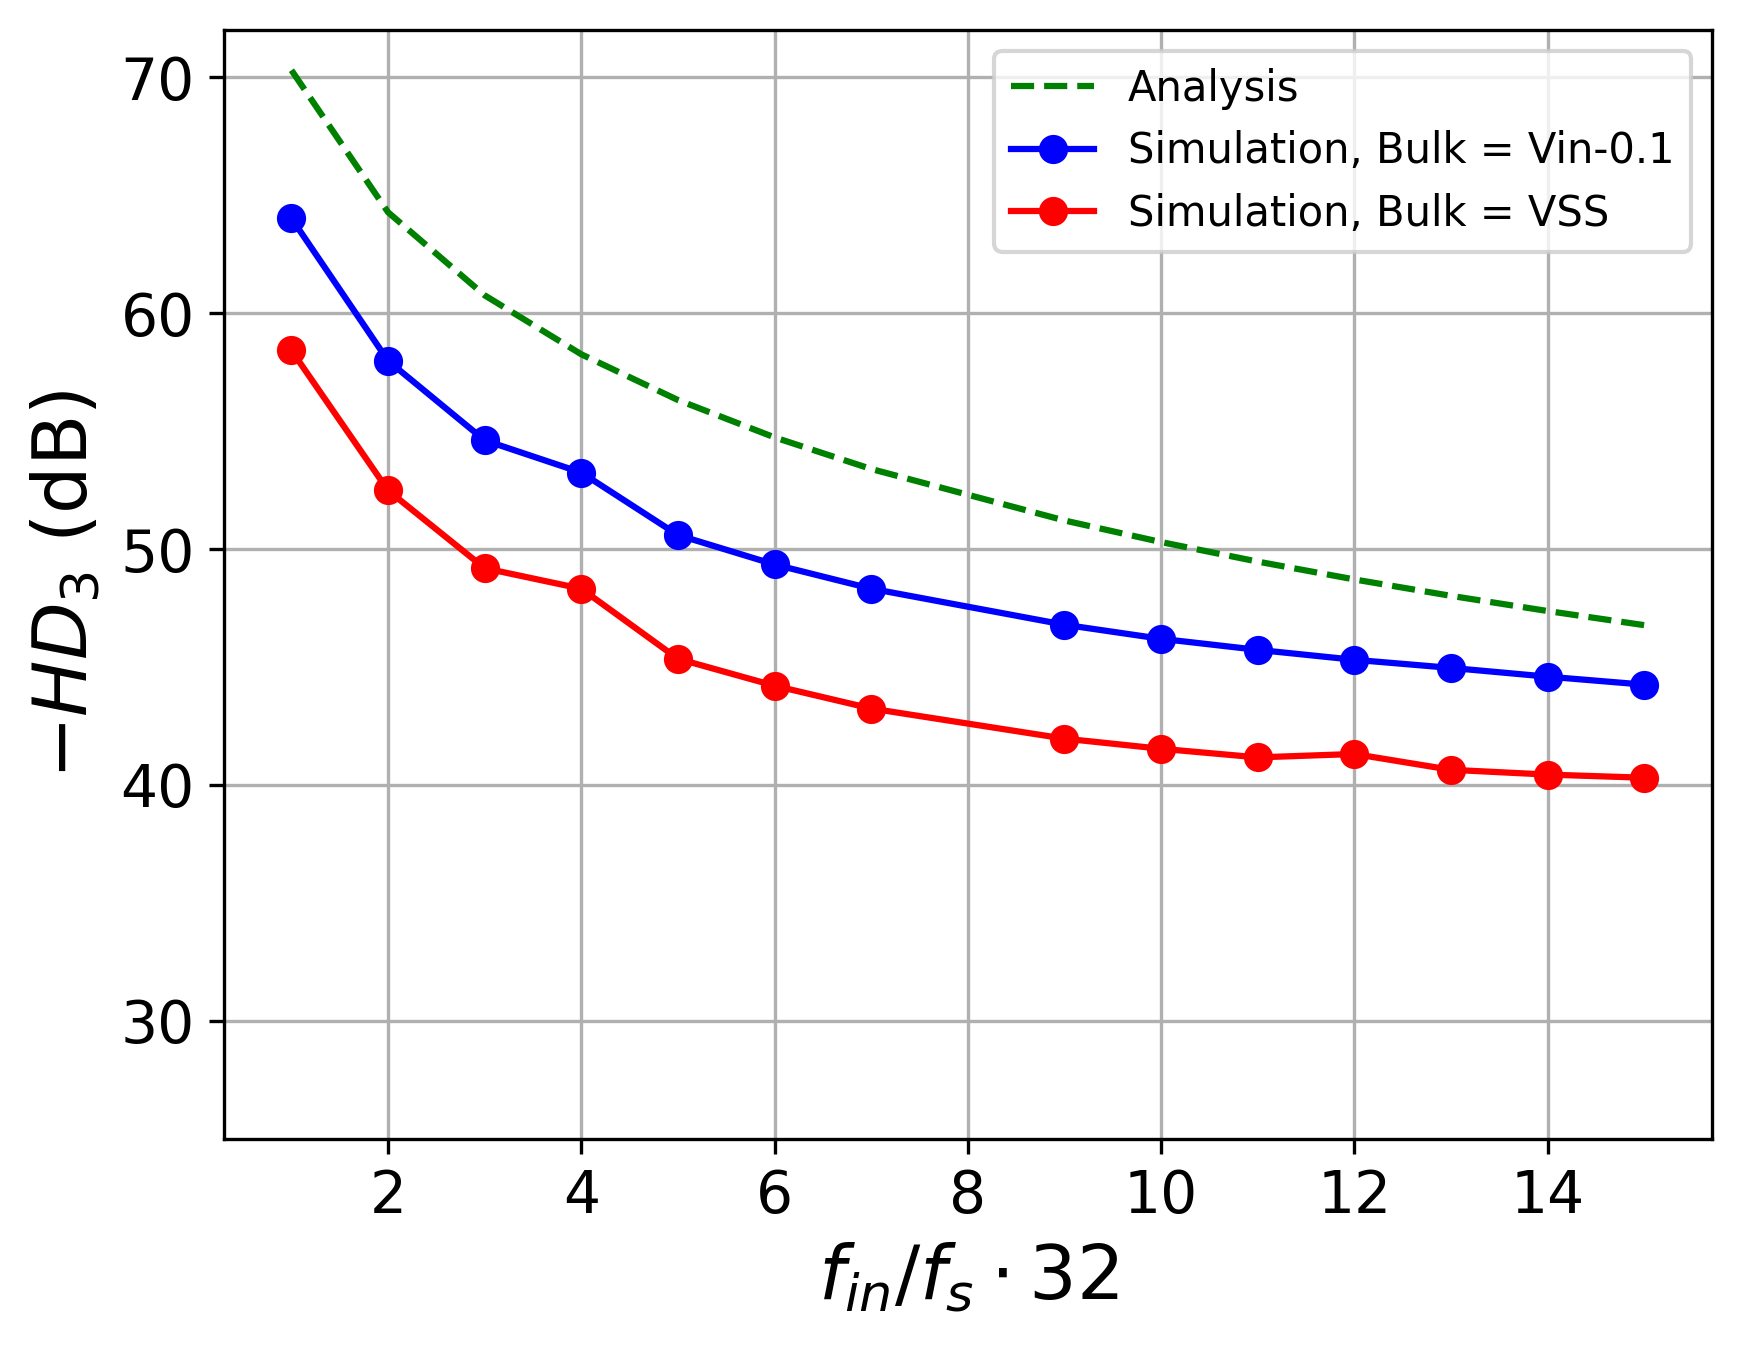

In [45]:
plt.rcParams['figure.dpi'] = 300
plt.plot(bins, hd3_calc, "g--", label='Analysis')
plt.plot(bins, hd3_bulk, "b-o", label='Simulation, Bulk = Vin-0.1')
plt.plot(bins, hd3, "r-o", label='Simulation, Bulk = VSS')
plt.grid()
plt.xlabel("$f_{in}/f_s \\cdot 32$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(25, 72)
plt.grid(True)
plt.legend()
plt.show()